[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/06_ai_engineering/22_ai_workflows.ipynb)

# 📓 Notebook 22 — AI-Assisted Workflows: LLMs, Prompts, and Automation

> **Module:** AI Engineering · **Estimated time:** 60–90 min · **Difficulty:** Intermediate

This notebook is the bridge between everything you've learned and what *modern* AI-driven work looks like. You will:

- Treat a Large Language Model (LLM) like any other Python function.
- Write prompts that are *reliable*, not just clever.
- Get **structured output** out of an LLM so the rest of your pipeline can use it.
- Classify and summarise a batch of real-looking customer feedback.
- Build a tiny **retrieval** workflow that grounds an LLM in your own documents.
- Put it all together in a small end-to-end automation pipeline.

> 🏢 **Back to Helpa — now we write code.** In NB 21 we met **Helpa**, the AI customer-support assistant for a small SaaS company, and we diagnosed *why* a "Just LLM" Helpa hallucinates and can't see your private data. This notebook is where Helpa stops being a thought experiment and becomes Python: we call a model, classify the support inbox, and build Helpa's first grounded answer. Same assistant — now with a keyboard.

> 🧭 **One mental model for the whole notebook: an LLM call is just a function call.** Picture it as `reply = f(messages)`. You hand in a list of messages, you get back a string. Every pattern below — system prompts, JSON output, batch loops, retrieval — is just *plumbing around that one function call*. We'll call this back at each section ("remember the *function-call* model — here it is again").

## 🔌 Runs entirely offline

This notebook uses a **`MockLLM`** that returns deterministic, sensible answers locally — so you can run every cell with **no API key and no internet access**. At the very end you'll see how to swap the mock for a real OpenAI or Anthropic client; the calling code is identical.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Explain what happens when you "call an LLM" — it's just a function call.
2. Use the **system / user / assistant** message structure correctly.
3. Apply the four core prompt patterns: **instructions**, **few-shot**, **structured output**, **chain-of-thought**.
4. Parse JSON output safely with `try / except`.
5. Classify and summarise a batch of records and report the results.
6. Build a tiny retrieval workflow (keyword-based RAG).
7. Reason about **cost, latency, and evaluation** for an AI feature.

## ✅ Prerequisites

Notebooks 1–13 — or at least 1–6 plus comfort with functions, dictionaries, and list comprehensions. Conceptually, NB 21 (what an LLM *is*) is the natural lead-in.

## 1. An LLM call is just a function call

Before we touch prompts, get the frame right — because it's the frame that keeps Helpa's code from turning into spaghetti. Forget the marketing copy for a moment. From your code's point of view, calling a Large Language Model looks like this:

```
response = llm(messages=[...], model="...", temperature=...)
```

You hand it a list of **messages** and some settings, and you get back a **string** (plus some metadata). The "intelligence" is on the other side of the wire. *Everything you'll do in this notebook is plumbing around that one function call.*

> 🧭 **The function-call mental model.** `reply = f(messages)`. That's Helpa, stripped to its skeleton. Notice it lines up exactly with NB 21's *loop* model: that `f` is the next-token loop (sample → append → repeat) running on a server somewhere; from your side it's just a function that takes messages and returns text.

### Why this perspective matters

If you treat the LLM as magic, your code will be brittle: prompt strings buried in business logic, no error handling, no tests. If you treat it as a *function*, you get the same engineering hygiene you'd apply to any third-party API: clear inputs, structured outputs, retries on failure, costs you can measure.

## 2. Our offline `MockLLM`

To keep this notebook runnable everywhere, we will use a small `MockLLM` class that imitates a real LLM. It is **not** intelligent — it follows hard-coded rules to produce plausible answers. That is more than enough to learn the *patterns*; you'll swap in a real model at the end.

Run the cell below first — every later cell uses this `llm` object.

In [1]:
# MockLLM lives in llm_providers.py so every AI notebook uses the same one.
# Swap it for any real provider by changing this one line — the rest of the
# notebook stays identical:
#
#     from llm_providers import OpenAILLM as LLM      # needs `pip install openai`
#     from llm_providers import AnthropicLLM as LLM   # needs `pip install anthropic`
#     from llm_providers import GoogleLLM as LLM      # needs `pip install google-generativeai`
#     from llm_providers import OllamaLLM as LLM      # local — needs Ollama running
import json, re, random, time
from textwrap import shorten

# Make the repo-root llm_providers.py importable regardless of which folder
# Jupyter launched the kernel in (it lives at the course root).
import sys, pathlib
_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p / "llm_providers.py").exists()), None)
if _root:                       # local checkout — use the repo's module
    sys.path.insert(0, str(_root))
else:                           # Colab / standalone — fetch it next to the notebook
    import urllib.request
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/ChrisW09/Python-for-AI-Driven-Automation"
        "/main/llm_providers.py", "llm_providers.py")

from llm_providers import MockLLM

llm = MockLLM(seed=42)
print('MockLLM ready ✅')

MockLLM ready ✅


> 🔌 **Using a real provider (OpenAI / Anthropic / Gemini / Ollama).**
> Every notebook in this module uses an offline `MockLLM` by default so you can run them without internet or API keys. Once you want real intelligence in the answers, swap one line — the unified interface in [`llm_providers.py`](../llm_providers.py) lets you use **OpenAI**, **Anthropic** (Claude), **Google** (Gemini), or a **local model via Ollama** without changing anything else.
> See the [LLM Providers Guide](./A1_llm_providers_guide.ipynb) for the swap-in instructions, model recommendations, and cost estimates.


## 3. Your first prompt — system + user messages

We have our function `f`; now let's look at its main argument — the `messages` list — because *how you fill it* is 90% of getting Helpa to behave. Modern LLM APIs use a **chat-style** format with a list of messages. Each message has a **role** and **content**:

- `"system"` — the *instructions*. Sets the model's job, tone, and constraints. Sent once.
- `"user"` — the actual input you want the model to act on.
- `"assistant"` — the model's previous reply (for multi-turn conversations).

The classic mistake of beginners is to cram everything into the user message. Instead, treat the system message as the **stable instructions** and the user message as the **variable input** — like a function and its arguments. (For Helpa: the system message is *"You are Helpa, a friendly SaaS support agent…"*; the user message is whatever the customer just typed.)

In [2]:
response = llm.chat(
    messages=[
        {"role": "system", "content":
            "You are a helpful assistant that summarises customer feedback in one sentence."},
        {"role": "user",   "content":
            "I love the new dashboard! It is so much faster and the dark mode is amazing. "
            "The mobile app still has some sync issues but overall it is a huge improvement."},
    ],
    model="mock-mini",
    temperature=0.0,
)

print("Reply :", response["text"])
print("Model :", response["model"])
print(f"Tokens: in={response['tokens_in']}, out={response['tokens_out']}")


Reply : I love the new dashboard!
Model : mock-mini
Tokens: in=47, out=6


> 💡 **How the mock decides what to return.** `MockLLM` is keyword-driven: it scans your **system** message for trigger words. Ask it to *"classify sentiment"* and it returns a label; include both *"json"* and *"sentiment"*/*"topic"* and it returns a JSON object; say *"summarise"* and it returns a one-sentence summary. A real model reads the *whole* prompt and is far more flexible — but every provider returns the **same dict shape** (`text`, `model`, `tokens_in`, `tokens_out`, `latency_s`), so the code you write here never changes. When a later cell "magically" gets JSON back, it is because its system prompt contains those trigger words.

> 💡 **Temperature.** A number between 0 and ~1 that controls randomness. Use `temperature=0` for classification, extraction, or anything you want to be *deterministic*. Use a slightly higher value (0.3–0.7) for creative tasks like rephrasing or brainstorming.

### 🔬 What actually happens inside a chat LLM call?

The cell above sent two messages and got a string back. That looked like one step — but it hides the single most important idea in all of LLM engineering. Let's slow it right down.

**A chat request is a *list of messages*, not a string.** Each message is a tiny dict with exactly two keys:

```python
{"role": "system",    "content": "..."}   # the instructions
{"role": "user",      "content": "..."}   # what a human said
{"role": "assistant", "content": "..."}   # what the model said back
```

The whole request is the list of those dicts, in order. Here is the anatomy of the call you just ran:

```text
  messages = [                                    ┐
    {"role":"system",  "content":"You are ..."}   │  ← role 1: the standing instructions
    {"role":"user",    "content":"I love the ..."}│  ← role 2: this turn's human input
  ]                                               ┘
        │
        │  the ENTIRE list is serialised and sent over the wire
        ▼
  ┌───────────────────────────┐
  │      the LLM (server)     │   reads ALL messages top-to-bottom,
  │  a pure text-prediction   │   then predicts the NEXT assistant message
  │        function           │
  └───────────────────────────┘
        │
        ▼
  "I love the new dashboard..."  → returns ONE new assistant message (a string + metadata)
```

**The three roles, and what each is *for*:**

| Role | Who writes it | What it's for |
|---|---|---|
| `system` | **you** (the developer) | Standing instructions: the job, tone, output format, rules. Set once, at the top. |
| `user` | **you / your end-user** | The actual input to act on this turn — the "argument" to the call. |
| `assistant` | **the model** | The model's replies. *You* paste these back in to remind the model what it already said. |


### The model has no memory — *you* hold the memory

Here is the part that trips up almost everyone. The model is **stateless**. It does **not** remember your previous message. There is no hidden notebook on the server with "your conversation" in it. Every call starts from a blank slate.

So how do ChatGPT-style apps "remember" what you said three turns ago? They don't — and neither does the model. The trick is embarrassingly simple:

> **"Conversation memory" is just you re-sending the entire growing list of messages every single turn.**

Each turn you take the previous list, **append the new user message**, send the *whole thing* again, then **append the model's reply** so it's there for next time. The list grows; the model stays forgetful.

```text
TURN 1  ─ you send ──►  [ system, user₁ ]
                                   │ model replies a₁
        ◄─ you store ──  [ system, user₁, a₁ ]

TURN 2  ─ you send ──►  [ system, user₁, a₁, user₂ ]      ← you RE-SEND turns 1 & 2
                                              │ model replies a₂
        ◄─ you store ──  [ system, user₁, a₁, user₂, a₂ ]

TURN 3  ─ you send ──►  [ system, user₁, a₁, user₂, a₂, user₃ ]   ← re-send EVERYTHING again
                                                       │ model replies a₃
        ◄─ you store ──  [ system, user₁, a₁, user₂, a₂, user₃, a₃ ]
```

Notice the list never shrinks, and the *same old messages get re-sent* on every turn. Two consequences fall straight out of that picture:

- **⚠️ Long chats cost more — every turn.** You pay for input tokens on *all* the messages you send, not just the newest one. A 40-turn chat re-sends turns 1–39 on turn 40. Cost grows roughly with the *square* of the conversation length. This is why production chat apps eventually *trim* or *summarise* old turns.
- **The system message is sent every time too.** It sits at the top of the list on every call, which is exactly why its instructions keep applying turn after turn — not because the model "remembers" them.

> 🧠 **The one mental model to keep.** *The model is a pure function of the messages you send it: `reply = f(messages)`. Same messages in → same kind of reply out. There is no hidden state. YOU hold the memory — by keeping and re-sending the list.*


In [3]:
# 🧪 PROOF (fully offline, stdlib only) — no network, no API key, no MockLLM needed.
# We write our own `fake_llm` so you can SEE that the model only ever receives a list
# of messages, and that "memory" is entirely on OUR side.

def fake_llm(messages):
    """A stateless stand-in for a real chat model.

    It keeps NO memory between calls. It simply INSPECTS the message list it was
    handed and predicts a reply from that list alone. Each call is independent:
    the only way it can 'know' earlier turns is if YOU included them in `messages`.
    """
    n = len(messages)
    last_user = next((m["content"] for m in reversed(messages)
                      if m["role"] == "user"), "(nothing)")
    # A real model predicts text; our fake just reports what it can see, to prove
    # the point that everything it knows came in through `messages`.
    return f"[saw {n} messages] you just said: {last_user!r}"

In [4]:
# --- Turn 1 ----------------------------------------------------------------
messages = [
    {"role": "system", "content": "You are a friendly travel assistant."},
    {"role": "user",   "content": "I want to visit Japan."},
]
reply = fake_llm(messages)
messages.append({"role": "assistant", "content": reply})   # ← WE store the reply
print("Turn 1 reply:", reply)
print("List length :", len(messages))

Turn 1 reply: [saw 2 messages] you just said: 'I want to visit Japan.'
List length : 3


In [5]:
# --- Turn 2 ----------------------------------------------------------------
messages.append({"role": "user", "content": "When should I go?"})  # ← append new user turn
reply = fake_llm(messages)                                          # ← re-send WHOLE list
messages.append({"role": "assistant", "content": reply})
print("\nTurn 2 reply:", reply)
print("List length :", len(messages))


Turn 2 reply: [saw 4 messages] you just said: 'When should I go?'
List length : 5


In [6]:
# --- Turn 3 ----------------------------------------------------------------
messages.append({"role": "user", "content": "What about food?"})
reply = fake_llm(messages)
messages.append({"role": "assistant", "content": reply})
print("\nTurn 3 reply:", reply)
print("List length :", len(messages), "  ← the list keeps GROWING; we re-send it all every turn")


Turn 3 reply: [saw 6 messages] you just said: 'What about food?'
List length : 7   ← the list keeps GROWING; we re-send it all every turn


In [7]:
# 🧪 PROOF that the model has NO memory of its own.
# Call fake_llm with ONLY the newest user message (forgetting to carry the history)
# and it literally cannot see the earlier turns — because nothing remembers them but us.

forgot_history = [
    {"role": "system", "content": "You are a friendly travel assistant."},
    {"role": "user",   "content": "What about food?"},   # turns 1 & 2 NOT included
]
print("With history dropped :", fake_llm(forgot_history))
print("  → it only sees 2 messages; the Japan context is GONE.\n")

# Now pass the full accumulated list from the previous cell — the context is back,
# purely because WE kept and re-sent it:
print("With history kept    :", fake_llm(messages))
print(f"  → it sees all {len(messages)} messages, because we held the memory, not the model.\n")

# And let's literally pretty-print the conversation we've been carrying:
print("The messages list WE maintain (this IS the 'conversation memory'):")
for i, m in enumerate(messages):
    print(f"  {i}: {m['role']:<9} | {m['content'][:48]}")


With history dropped : [saw 2 messages] you just said: 'What about food?'
  → it only sees 2 messages; the Japan context is GONE.

With history kept    : [saw 7 messages] you just said: 'What about food?'
  → it sees all 7 messages, because we held the memory, not the model.

The messages list WE maintain (this IS the 'conversation memory'):
  0: system    | You are a friendly travel assistant.
  1: user      | I want to visit Japan.
  2: assistant | [saw 2 messages] you just said: 'I want to visit
  3: user      | When should I go?
  4: assistant | [saw 4 messages] you just said: 'When should I g
  5: user      | What about food?
  6: assistant | [saw 6 messages] you just said: 'What about food


### One knob to know: `temperature`

You'll see `temperature` on every chat call. In one line: **it controls how *random* the model's word-by-word sampling is.**

- `temperature=0` → the model (almost) always picks its single most likely next word → **deterministic, repeatable** output. Use it for classification, extraction, JSON — anything you'll parse with code.
- `temperature≈0.7` → the model samples more loosely among likely words → **more varied, creative** output. Use it for brainstorming, rephrasing, writing copy.

It does **not** make the model "smarter" or give it memory — it only changes *which* of the plausible next words gets picked. Memory is still entirely the messages list you carry; `temperature` just nudges the sampling on top of it.

> 🎯 **Tying it together.** A chat call is `reply = f(messages, temperature)`. The `messages` list — system + the growing user/assistant history — is the *entire* world the model sees. There is no hidden state on the server: **you** assemble the list, **you** re-send it each turn, and `temperature` decides how predictably the model samples its reply. Every pattern in the rest of this notebook (few-shot, RAG, batch) is just a different way of *building that list*.


---

### ✋ Quick exercise (~2 min) — You hold the memory

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The model is stateless: "memory" is just the message list *you* keep and re-send. Continue the travel chat below by **appending a new user turn** (`"What's the weather like?"`), then call `fake_llm(messages)`. Predict how many messages it reports seeing.

```python
messages = [
    {"role": "system",    "content": "You are a friendly travel assistant."},
    {"role": "user",      "content": "I want to visit Japan."},
    {"role": "assistant", "content": "Japan is wonderful!"},
]
```

In [8]:
# ✍️ Your turn 👇
messages = [
    {"role": "system",    "content": "You are a friendly travel assistant."},
    {"role": "user",      "content": "I want to visit Japan."},
    {"role": "assistant", "content": "Japan is wonderful!"},
]
# Append a new user message, then call fake_llm(messages) and print the reply.


<details>
<summary>✅ <b>Solution</b></summary>

```python
messages.append({"role": "user", "content": "What's the weather like?"})
print(fake_llm(messages))   # -> [saw 4 messages] you just said: "What's the weather like?"
```

Because the model is stateless, the only context it has is the list you pass; appending the new turn keeps the Japan history alive and `fake_llm` now sees all 4 messages.
</details>

## 4. The four core prompt patterns

Earlier we filled the `messages` list with a single system+user pair. Now we level up *what goes in those messages* — because the content of the prompt is the one lever you'll pull on every single Helpa task. You'll see hundreds of "prompt engineering" tips on the internet. They almost all boil down to **four patterns**.

> 🧭 **Still the same function call.** Each pattern below changes only the `messages` you pass to `f` — never `f` itself. Remember the function-call model: you're shaping the *input*, then reading the *output*.

### Pattern 1 — Clear instructions

The single biggest lever. Be explicit about:

1. **Role** — *"You are a senior support analyst."*
2. **Task** — *"Classify the customer's sentiment."*
3. **Constraints** — *"Reply with exactly one of: positive, neutral, negative."*

Vague prompts produce vague output. Boring as that sounds, it is what works.

In [9]:
# A *good* classification prompt: role + task + constraint
SYSTEM_PROMPT = (
    "You are a customer-experience analyst. "
    "Classify the sentiment of the customer message as exactly one of: "
    "positive, neutral, negative. Reply with only the label — no extra words."
)

def classify_sentiment(text):
    r = llm.chat(
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": text},
        ],
        temperature=0.0,
    )
    return r["text"].strip().lower()


for msg in [
    "Absolutely love the latest update — it saved me hours!",
    "The app crashed three times today. I'm so frustrated.",
    "The form has 12 fields. Some of them are useful.",
]:
    print(f"  {classify_sentiment(msg):<8}  ←  {msg[:60]}")


  positive  ←  Absolutely love the latest update — it saved me hours!
  neutral   ←  The app crashed three times today. I'm so frustrated.
  neutral   ←  The form has 12 fields. Some of them are useful.


### Pattern 2 — Few-shot examples

Instead of *describing* the task in words, *show* the model two or three examples. Especially useful when:

- the task is hard to describe precisely,
- you want a very specific output format,
- the model keeps drifting away from your desired style.

The shape is always: `instructions` → `example 1` → `example 2` → … → `the real input`.

In [10]:
FEW_SHOT_SYSTEM = (
    "You classify the topic of customer messages. "
    "Choose exactly one of: billing, tech, feature, other. "
    "Reply with only the label."
)

# A few examples wrapped as user/assistant turns
few_shot_messages = [
    {"role": "system",    "content": FEW_SHOT_SYSTEM},
    {"role": "user",      "content": "I was charged twice for my subscription last month."},
    {"role": "assistant", "content": "billing"},
    {"role": "user",      "content": "Could you add dark mode to the mobile app?"},
    {"role": "assistant", "content": "feature"},
    {"role": "user",      "content": "I can't log in — the password reset link is broken."},
    {"role": "assistant", "content": "tech"},
]

def classify_topic(text):
    msgs = few_shot_messages + [{"role": "user", "content": text}]
    r = llm.chat(messages=msgs, temperature=0.0)
    return r["text"].strip().lower()


for msg in [
    "My invoice doesn't match my plan — please refund the difference.",
    "I keep getting a 500 error when uploading a file.",
    "Would love it if you supported CSV export.",
]:
    print(f"  {classify_topic(msg):<8}  ←  {msg}")


  billing   ←  My invoice doesn't match my plan — please refund the difference.
  tech      ←  I keep getting a 500 error when uploading a file.
  other     ←  Would love it if you supported CSV export.


### Pattern 3 — Structured (JSON) output

This is the **single most useful pattern for automation**. If you ask the model to "reply in JSON with keys X, Y, Z" you can `json.loads()` the reply and use it like any other Python data.

You'll do this every time you build an AI feature that hands its result to another step in a pipeline.

In [11]:
STRUCTURED_SYSTEM = (
    "You analyse customer messages. "
    "Return a JSON object with exactly two keys: "
    "  - 'sentiment': one of positive | neutral | negative\n"
    "  - 'topic':     one of billing | tech | feature | other\n"
    "Reply with the JSON only. No prose, no markdown fences."
)

def analyse(text):
    r = llm.chat(
        messages=[
            {"role": "system", "content": STRUCTURED_SYSTEM},
            {"role": "user",   "content": text},
        ],
        temperature=0.0,
    )

    # The model's reply is a JSON string — parse it.
    try:
        return json.loads(r["text"])
    except json.JSONDecodeError:
        # Always have a fallback for when the model misbehaves
        return {"sentiment": "unknown", "topic": "unknown", "_raw": r["text"]}


result = analyse("My password reset link is broken and I can't log in. Please help!")
print(result)
print(f"\nSentiment: {result['sentiment']!r}, Topic: {result['topic']!r}")


{'sentiment': 'negative', 'topic': 'tech'}

Sentiment: 'negative', Topic: 'tech'


> ⚠️ **Always wrap `json.loads` in `try / except`.** Real LLMs occasionally include markdown fences (```` ```json ... ``` ````), trailing prose, or a typo. Defensive parsing is non-negotiable in production.

### Pattern 4 — Chain-of-thought (CoT)

For multi-step reasoning, ask the model to think *step by step* before giving the final answer. The phrasing literally is: *"First, list the steps. Then give the answer."* It works because the model can use its own intermediate output as scratch space — each reasoning token it writes becomes context it conditions on for the next one.

We won't dwell on it here — the mock isn't smart enough to demonstrate — but remember the trick. When the model gets an answer wrong on a reasoning-heavy task, add "let's think step by step" and try again.

---

### ✋ Quick exercise (~2 min) — Defensive JSON parsing

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

A real model ignored "no markdown fences" and wrapped its structured reply in a code fence (exactly the failure the ⚠️ note warned about). **Strip the fences and `json.loads` the result**, falling back to `{"sentiment": "unknown", "topic": "unknown"}` if parsing still fails.

```python
raw = '```json\n{"sentiment": "negative", "topic": "tech"}\n```'
```

In [12]:
# ✍️ Your turn 👇
raw = '```json\n{"sentiment": "negative", "topic": "tech"}\n```'
# Clean the fences, then parse defensively into a dict.


<details>
<summary>✅ <b>Solution</b></summary>

```python
fence = "`" * 3                       # the markdown fence, built so we never type ``` literally
cleaned = raw.strip().removeprefix(fence + "json").removeprefix(fence).removesuffix(fence).strip()
try:
    parsed = json.loads(cleaned)
except json.JSONDecodeError:
    parsed = {"sentiment": "unknown", "topic": "unknown"}
print(parsed)   # {'sentiment': 'negative', 'topic': 'tech'}
```

This is Pattern 3 (structured output) plus the non-negotiable `try/except` habit: strip the stray markdown fences first, then parse — and always keep a fallback for when the model misbehaves.
</details>

## 5. Batch processing — classify a whole inbox

So far Helpa has handled one message at a time. But the real win of "an LLM call is just a function call" is that *you can put a function in a loop*. This is where Python loops + LLM calls really shine. Suppose you have 50 fresh pieces of customer feedback overnight. You want a sentiment, a topic, and a one-line summary for each — Helpa triaging the whole inbox while you sleep.

In [13]:
# A small but realistic batch of customer feedback
feedback_batch = [
    "I love the new dashboard! It's much faster and the dark mode is amazing.",
    "The app crashed three times today. I'm so frustrated with this bug.",
    "Could you please add CSV export? I really need it for my reports.",
    "My invoice doesn't match my plan — please refund the difference of $45.",
    "Everything works fine, no complaints, no praise either.",
    "The login is broken after the latest update. I can't access my account.",
    "Fantastic support team, they resolved my issue in minutes. Thank you!",
    "Why is the renewal price so high? I'm considering cancelling my subscription.",
    "The new feature is great but the loading is really slow on mobile.",
    "Please add support for Markdown in the editor. It would be a huge help.",
]
print(f"Batch size: {len(feedback_batch)}")


Batch size: 10


In [14]:
# Run all of them through the structured-output analyser
SYSTEM = (
    "You analyse customer messages. "
    "Return JSON with keys 'sentiment' (positive/neutral/negative) and "
    "'topic' (billing/tech/feature/other). "
    "Reply with the JSON only."
)

def analyse_and_summarise(text):
    # 1) Sentiment + topic in one structured call
    r1 = llm.chat(
        messages=[{"role": "system", "content": SYSTEM},
                  {"role": "user",   "content": text}],
        temperature=0.0,
    )
    try:
        labels = json.loads(r1["text"])
    except json.JSONDecodeError:
        labels = {"sentiment": "unknown", "topic": "unknown"}

    # 2) A short summary in a second call
    r2 = llm.chat(
        messages=[{"role": "system", "content": "Summarise the customer message in one sentence."},
                  {"role": "user",   "content": text}],
        temperature=0.0,
    )
    labels["summary"] = r2["text"].strip()
    labels["tokens_in"]  = r1["tokens_in"]  + r2["tokens_in"]
    labels["tokens_out"] = r1["tokens_out"] + r2["tokens_out"]
    return labels

In [15]:
# Process the batch
results = [analyse_and_summarise(msg) for msg in feedback_batch]

# Show first few results
for msg, res in list(zip(feedback_batch, results))[:5]:
    print(f"[{res['sentiment']:<8} / {res['topic']:<7}]  {res['summary']}")

[positive / other  ]  I love the new dashboard!
[negative / tech   ]  The app crashed three times today.
[neutral  / feature]  Could you please add CSV export?
[negative / billing]  My invoice doesn't match my plan — please refund the difference of $45.
[neutral  / other  ]  Everything works fine, no complaints, no praise either.


### A KPI report on the batch

Once each item has structured fields, aggregating is just Python — exactly the techniques from Notebooks 2 and 3.

In [16]:
from collections import Counter

n = len(results)
sentiments = Counter(r["sentiment"] for r in results)
topics     = Counter(r["topic"]     for r in results)

tokens_in_total  = sum(r["tokens_in"]  for r in results)
tokens_out_total = sum(r["tokens_out"] for r in results)

price_in_per_1k  = 0.0006
price_out_per_1k = 0.0024
cost = (tokens_in_total / 1000 * price_in_per_1k +
        tokens_out_total / 1000 * price_out_per_1k)

print(f"📊 Feedback batch — {n} messages")
print("-" * 40)
print("Sentiment mix:")
for label, count in sentiments.most_common():
    print(f"  {label:<10}: {count:>2}  ({count/n:.0%})")
print("\nTopic mix:")
for label, count in topics.most_common():
    print(f"  {label:<10}: {count:>2}  ({count/n:.0%})")
print(f"\nTokens in : {tokens_in_total:,}")
print(f"Tokens out: {tokens_out_total:,}")
print(f"Est. cost : ${cost:.4f}")


📊 Feedback batch — 10 messages
----------------------------------------
Sentiment mix:
  neutral   :  5  (50%)
  negative  :  3  (30%)
  positive  :  2  (20%)

Topic mix:
  other     :  3  (30%)
  tech      :  3  (30%)
  feature   :  2  (20%)
  billing   :  2  (20%)

Tokens in : 778
Tokens out: 269
Est. cost : $0.0011


**The cost, as a picture.** Output tokens (orange) stack on top of input tokens (blue) for each message — a quick read on what's actually driving the bill.

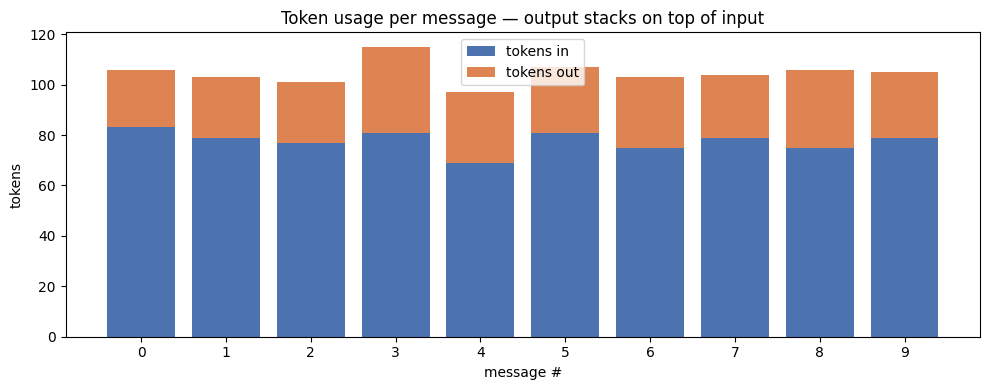

In [17]:
import matplotlib.pyplot as plt

idx  = range(len(results))
tin  = [r["tokens_in"]  for r in results]
tout = [r["tokens_out"] for r in results]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(idx, tin,  label="tokens in",  color="#4C72B0")
ax.bar(idx, tout, bottom=tin, label="tokens out", color="#DD8452")
ax.set(xlabel="message #", ylabel="tokens",
       title="Token usage per message — output stacks on top of input")
ax.set_xticks(list(idx))
ax.legend()
plt.tight_layout(); plt.show()

**The KPI report as a chart.** The printed mix is fine for one batch; a quick bar chart is what you'd actually put on a dashboard the business reads every morning.


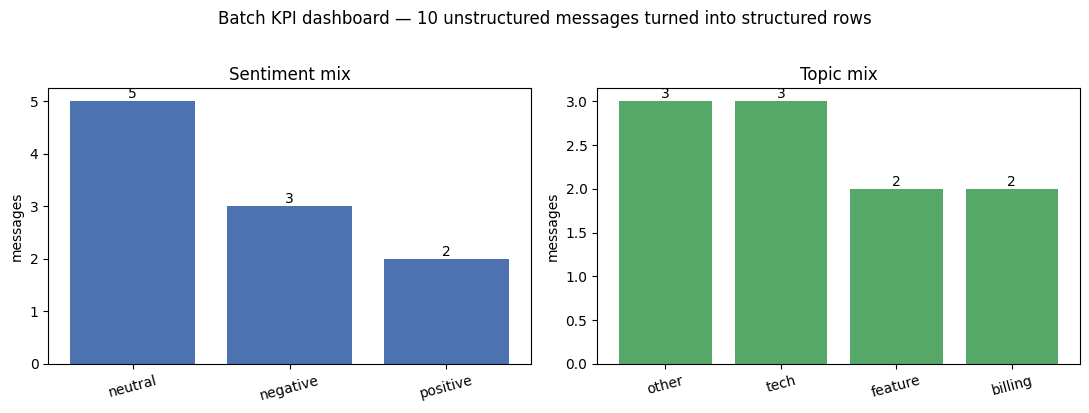

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, counter, title, color in [(axes[0], sentiments, "Sentiment mix", "#4C72B0"),
                                  (axes[1], topics,     "Topic mix",     "#55A868")]:
    items  = counter.most_common()
    labels = [k for k, _ in items]
    vals   = [v for _, v in items]
    bars = ax.bar(labels, vals, color=color)
    ax.bar_label(bars)
    ax.set(title=title, ylabel="messages")
    ax.tick_params(axis="x", rotation=15)
fig.suptitle(f"Batch KPI dashboard — {n} unstructured messages turned into structured rows", y=1.02)
plt.tight_layout(); plt.show()


> **How to read it.** Same numbers as the printed report, but a stakeholder sees the sentiment/topic skew in one glance — and it updates automatically as new feedback flows through the pipeline.


**Stop and notice what just happened.** We turned a 10-item pile of unstructured text into a structured table of sentiments, topics and summaries, *plus* a cost report — in under 30 lines of code. That is the entire point of AI-assisted automation: turn the messy stuff at the edges of your business into clean rows you can act on.

---

### ✋ Quick exercise (~2 min) — Read the batch KPIs

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Once each item is a structured dict, aggregating is just Python. For the mini-batch below, count how many messages are `"negative"` and print that as a share of the batch (e.g. `2/4 = 50%`).

```python
results_demo = [
    {"sentiment": "positive", "topic": "feature"},
    {"sentiment": "negative", "topic": "tech"},
    {"sentiment": "negative", "topic": "billing"},
    {"sentiment": "neutral",  "topic": "other"},
]
```

In [19]:
# ✍️ Your turn 👇
results_demo = [
    {"sentiment": "positive", "topic": "feature"},
    {"sentiment": "negative", "topic": "tech"},
    {"sentiment": "negative", "topic": "billing"},
    {"sentiment": "neutral",  "topic": "other"},
]
# Count the 'negative' items and print their share of the batch.


<details>
<summary>✅ <b>Solution</b></summary>

```python
from collections import Counter
counts = Counter(r["sentiment"] for r in results_demo)
n = len(results_demo)
neg = counts["negative"]
print(f"negative: {neg}/{n}  ({neg/n:.0%})")   # negative: 2/4  (50%)
```

Same move as the KPI cell: a `Counter` over a generator turns a list of structured dicts into an aggregate, and dividing by `len` gives the share — plain Python on clean rows.
</details>

## 6. A tiny retrieval workflow

Here's the moment we promised back in NB 21. Helpa is fluent, but it doesn't *know your product* — ask it about your refund policy and it'll cheerfully invent one. What if you want the model to answer questions **about your own data** — a knowledge base, your product docs, your company policies?

The technique is called **Retrieval-Augmented Generation (RAG)** — it's the second rung of NB 21's ladder (LLM → LLM + RAG → Agent):

```
question  ─┐
            ├──→ retrieve top-k relevant snippets ──→ LLM ──→ answer
your docs ─┘
```

> 🧭 **Still the same function call.** RAG doesn't change `f` — it changes the `messages` you pass in, stuffing the retrieved snippets into the context *before* the question. You're handing the loop something real to ground on. That's the entire cure for the hallucination we diagnosed in NB 21.

In a production system the retrieval step uses **embeddings** (vector search). For learning the pattern, a simple **keyword overlap** scorer is enough — and works without any extra dependencies. (NB 23 upgrades this exact retriever to true semantic search.)

In [20]:
# A tiny in-memory "knowledge base"
docs = [
    ("billing.refunds",
     "Refunds are issued within 5 business days. Customers can request a refund "
     "from the Billing page if the request is within 30 days of purchase."),

    ("billing.subscriptions",
     "Subscriptions renew automatically. To cancel, go to Settings → Billing "
     "and click 'Cancel subscription'. You will retain access until the period ends."),

    ("tech.password",
     "If you can't log in, use the 'Forgot password' link on the sign-in page. "
     "Reset emails arrive within 5 minutes; check your spam folder if missing."),

    ("tech.errors",
     "A 500 error usually indicates a temporary backend issue. Wait 60 seconds "
     "and retry. If the error persists, contact support with the trace ID shown."),

    ("feature.exports",
     "CSV and JSON exports are available on Pro plans. Use the 'Export' button "
     "in the top-right corner of any report. XLSX export is on the roadmap."),
]
print(f"Knowledge base has {len(docs)} documents.")


Knowledge base has 5 documents.


In [21]:
def keyword_score(query, doc_text):
    """Number of distinct query words that appear in the document."""
    q_words = set(re.findall(r'[a-zA-Z]+', query.lower()))
    d_words = set(re.findall(r'[a-zA-Z]+', doc_text.lower()))
    return len(q_words & d_words)


def retrieve(query, docs, k=2):
    scored = [(keyword_score(query, text), name, text) for name, text in docs]
    scored.sort(reverse=True)            # highest score first
    return [(name, text) for score, name, text in scored[:k] if score > 0]


# Try it
query = "How do I get a refund for my subscription?"
top = retrieve(query, docs, k=2)
for name, text in top:
    print(f"  → {name}\n     {text}\n")


  → billing.refunds
     Refunds are issued within 5 business days. Customers can request a refund from the Billing page if the request is within 30 days of purchase.

  → tech.errors
     A 500 error usually indicates a temporary backend issue. Wait 60 seconds and retry. If the error persists, contact support with the trace ID shown.



**Why those two docs?** Retrieval is just *ranking by relevance*. Here's the keyword-overlap score for every document — the green bars are the top-`k` snippets `retrieve()` actually fed to the model.

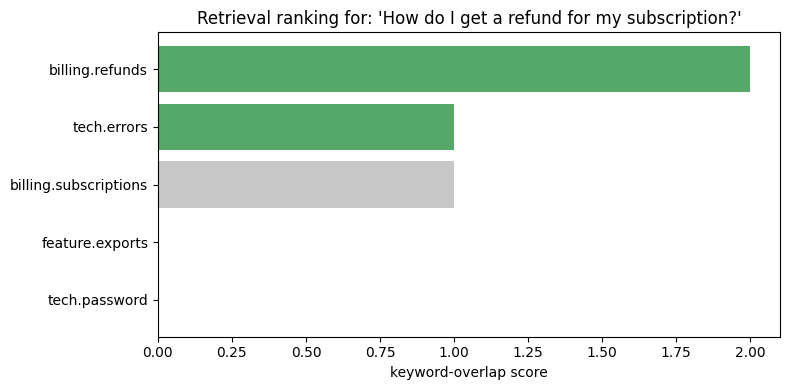

In [22]:
import matplotlib.pyplot as plt

names  = [name for name, _ in docs]
scores = [keyword_score(query, text) for _, text in docs]
top_k  = {name for name, _ in top}                           # the ones retrieve() kept
order  = sorted(range(len(docs)), key=lambda i: scores[i])   # low->high for barh

colors = ["#55A868" if names[i] in top_k else "#C7C7C7" for i in order]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([names[i] for i in order], [scores[i] for i in order], color=colors)
ax.set(xlabel="keyword-overlap score",
       title=f"Retrieval ranking for: {query!r}")
plt.tight_layout(); plt.show()

In [23]:
def rag_answer(question, docs):
    snippets = retrieve(question, docs, k=2)
    if not snippets:
        context = "(no relevant snippets found)"
    else:
        context = "\n\n".join(f"[{name}] {text}" for name, text in snippets)

    system = (
        "You answer the user's question using ONLY the context provided. "
        "If the context does not contain the answer, say so clearly."
    )
    user = f"Context:\n{context}\n\nQuestion: {question}"

    r = llm.chat(
        messages=[{"role": "system", "content": system},
                  {"role": "user",   "content": user}],
        temperature=0.0,
    )
    return r["text"], snippets


answer, used = rag_answer("How do I cancel my subscription?", docs)
print("Answer:", answer)
print("\nSources used:")
for name, _ in used:
    print(f"  - {name}")


Answer: Based on the provided context, here is a short answer. You asked: Context: [billing.subscriptions] Subscriptions renew automatically.

Sources used:
  - billing.subscriptions


> 🎯 **What's the win here?** Without retrieval, the model would have to *guess* your refund policy. With retrieval, it answers from your *actual* policy — so you can deploy the same model across very different domains by just swapping the knowledge base.

> 💡 **In production** you'd replace `keyword_score` with vector embeddings (e.g. `text-embedding-3-small`) plus a vector store. The control-flow shape — retrieve → assemble context → call the model — stays *identical*.

---

### ✋ Quick exercise (~2 min) — Predict the retrieval

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Retrieval runs *before* the model and needs no API call. Using the existing `retrieve()` and `docs`, fetch the single best snippet (`k=1`) for the question below. Predict which doc name comes back — then run it to check.

```python
question = "Can I export my report to CSV?"
```

In [24]:
# ✍️ Your turn 👇
question = "Can I export my report to CSV?"
# Call retrieve(...) with k=1 and print the doc name it returns.


<details>
<summary>✅ <b>Solution</b></summary>

```python
top = retrieve(question, docs, k=1)
print(top[0][0])   # feature.exports
```

`keyword_score` counts overlapping words, so "export"/"CSV"/"report" make `feature.exports` the highest-scoring document — the retrieval step that grounds the model's answer, with no network needed.
</details>

## 7. Cost, latency, evaluation — the engineer's checklist

Helpa now works on a handful of examples. But "cool, it works on my five examples" is *not* a production system — and the difference is the part nobody screenshots: cost, latency, and a number that says how often it's *right*. Before you ship, run a few back-of-the-envelope numbers.

In [25]:
# A small evaluation set with known correct labels
eval_set = [
    ("I love the new dark mode!",                                "positive"),
    ("Crashed again. Furious.",                                  "negative"),
    ("Could you add a CSV export?",                              "neutral"),     # a request, not a sentiment
    ("Refund requested — wrong charge on invoice.",              "negative"),
    ("Works fine, no issues.",                                   "positive"),    # neutral-ish too — tricky
]

correct = 0
total_tokens_in  = 0
total_tokens_out = 0
total_latency_s  = 0.0

In [26]:
for text, expected in eval_set:
    r = llm.chat(
        messages=[
            {"role": "system", "content":
                "Classify the sentiment as positive, neutral, or negative. Reply with only the label."},
            {"role": "user", "content": text},
        ],
        temperature=0.0,
    )
    pred = r["text"].strip().lower()
    ok   = pred == expected
    correct += int(ok)
    total_tokens_in  += r["tokens_in"]
    total_tokens_out += r["tokens_out"]
    total_latency_s  += r["latency_s"]
    mark = "✅" if ok else "❌"
    print(f"  {mark}  expected={expected:<8}  got={pred:<8}  ←  {text[:50]}")

  ✅  expected=positive  got=positive  ←  I love the new dark mode!
  ❌  expected=negative  got=neutral   ←  Crashed again. Furious.
  ✅  expected=neutral   got=neutral   ←  Could you add a CSV export?
  ✅  expected=negative  got=negative  ←  Refund requested — wrong charge on invoice.
  ❌  expected=positive  got=neutral   ←  Works fine, no issues.


In [27]:
# Headline numbers
n = len(eval_set)
acc = correct / n
cost = (total_tokens_in / 1000 * 0.0006 +
        total_tokens_out / 1000 * 0.0024)
print(f"\nAccuracy : {acc:.0%}  ({correct}/{n})")
print(f"Latency  : {total_latency_s*1000:.1f} ms total ({total_latency_s/n*1000:.1f} ms / call)")
print(f"Cost     : ${cost:.4f} for the whole eval set")


Accuracy : 60%  (3/5)
Latency  : 0.0 ms total (0.0 ms / call)
Cost     : $0.0001 for the whole eval set


**A useful habit.** Every AI feature you ship should have a small "regression set" like this — 50–500 hand-labelled examples you can re-run in 30 seconds whenever you change a prompt, a model, or a temperature. Without it, every prompt tweak is a gamble.

## 8. Going live with a real model

This is the payoff of the function-call mental model. Everything you've written so far works with *any* chat-style LLM. To turn the mock Helpa into a real one, you change one function — `llm.chat()` — and your application code stays the same.

Here are the **shapes** of the two most common SDKs. **You should NOT run these cells in this notebook** unless you have a key set up — they are here as a reference you can copy.

### Pattern: OpenAI

```python
# pip install openai
# export OPENAI_API_KEY=...

from openai import OpenAI
client = OpenAI()                            # picks up OPENAI_API_KEY from env

def chat(messages, model="gpt-5.4-mini", temperature=0.0):
    resp = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=temperature,
    )
    return {
        "text":       resp.choices[0].message.content,
        "model":      resp.model,
        "tokens_in":  resp.usage.prompt_tokens,
        "tokens_out": resp.usage.completion_tokens,
    }
```

### Pattern: Anthropic

```python
# pip install anthropic
# export ANTHROPIC_API_KEY=...

import anthropic
client = anthropic.Anthropic()               # picks up ANTHROPIC_API_KEY from env

def chat(messages, model="claude-haiku-4-5", temperature=0.0):
    # Anthropic puts the system message in a separate parameter
    system = next((m["content"] for m in messages if m["role"] == "system"), "")
    user_assistant = [m for m in messages if m["role"] != "system"]

    resp = client.messages.create(
        model=model,
        system=system,
        max_tokens=1024,
        temperature=temperature,
        messages=user_assistant,
    )
    return {
        "text":       resp.content[0].text,
        "model":      resp.model,
        "tokens_in":  resp.usage.input_tokens,
        "tokens_out": resp.usage.output_tokens,
    }
```

> 🔐 **Never paste API keys into a notebook.** Read them from environment variables (`os.getenv("OPENAI_API_KEY")`) or a `.env` file plus `python-dotenv`. Keys in notebooks tend to end up in git history.

> 💡 The function-call shape is the same. That is why we built `MockLLM.chat` with the same signature — the rest of your pipeline doesn't care which engine answers.

## 🧪 Practice exercises

### Exercise 1 — ⭐ A safer JSON parser

Write a function `safe_json(text)` that:

1. Strips markdown code fences (```` ```json ... ``` ````) if present.
2. Returns the parsed object on success.
3. Returns `None` (not a crash) on `JSONDecodeError`.

Then test it on these three strings:

```python
'{"a": 1}'
'```json\n{"a": 1}\n```'
'this is not JSON'
```

In [28]:
# Your code here  👇
def safe_json(text):
    pass


<details>
<summary>💡 <b>Solution</b></summary>

```python
import json, re

def safe_json(text):
    if text is None:
        return None
    # Drop markdown fences like ```json ... ``` or ``` ... ```
    cleaned = re.sub(r"^```(?:json)?\s*|\s*```$", "", text.strip(), flags=re.IGNORECASE | re.MULTILINE)
    try:
        return json.loads(cleaned)
    except json.JSONDecodeError:
        return None

print(safe_json('{"a": 1}'))                            # {'a': 1}
print(safe_json('```json\n{"a": 1}\n```'))             # {'a': 1}
print(safe_json("this is not JSON"))                     # None
```

**Why this matters.** Every batch you run will have *some* malformed responses. Defensive parsing keeps one bad reply from killing the whole job.
</details>

### Exercise 2 — ⭐⭐ Classify and split

Given the batch below, build two lists: one of messages classified as `"negative"`, one of everything else. Use the `analyse` function we built earlier — or write your own one-line version with `classify_sentiment`.

In [29]:
batch_b = [
    "Great product, would recommend!",
    "The app keeps crashing on launch.",
    "Pricing page is unclear.",
    "Customer support resolved my issue quickly. Thanks!",
    "Refund taking forever. Very disappointed.",
]

# Your code here  👇
negatives = []
others    = []


<details>
<summary>💡 <b>Solution</b></summary>

```python
negatives = []
others    = []

for msg in batch_b:
    if classify_sentiment(msg) == "negative":
        negatives.append(msg)
    else:
        others.append(msg)

print("Negatives:")
for m in negatives:
    print("  -", m)
print("\nOthers:")
for m in others:
    print("  -", m)
```

**More Pythonic (one-liner):**

```python
negatives = [m for m in batch_b if classify_sentiment(m) == "negative"]
others    = [m for m in batch_b if classify_sentiment(m) != "negative"]
```

Note the comprehension version calls the LLM twice per message. For long batches, prefer the explicit loop so each message is classified once.
</details>

### Exercise 3 — ⭐⭐ Add a confidence band to the RAG answer

Modify `rag_answer` to also return a *confidence band* based on the number of high-scoring snippets retrieved:

- **high** — at least 2 snippets each with a score ≥ 2
- **medium** — at least 1 snippet with a score ≥ 2
- **low** — otherwise

This lets a downstream system decide whether to show the AI answer or escalate to a human.

In [30]:
# Your code here  👇
def rag_answer_with_confidence(question, docs):
    pass


<details>
<summary>💡 <b>Solution</b></summary>

```python
def rag_answer_with_confidence(question, docs):
    scored = [(keyword_score(question, text), name, text) for name, text in docs]
    scored.sort(reverse=True)
    snippets = [(name, text) for score, name, text in scored[:3] if score > 0]
    high_scores = [score for score, *_ in scored[:3] if score >= 2]

    if len(high_scores) >= 2:
        confidence = "high"
    elif len(high_scores) >= 1:
        confidence = "medium"
    else:
        confidence = "low"

    if not snippets:
        return {"answer": "(no relevant snippets found)", "confidence": "low", "sources": []}

    context = "\n\n".join(f"[{name}] {text}" for name, text in snippets)
    r = llm.chat(
        messages=[
            {"role": "system", "content":
                "You answer the user's question using ONLY the context provided."},
            {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}"},
        ],
        temperature=0.0,
    )
    return {
        "answer":     r["text"],
        "confidence": confidence,
        "sources":    [name for name, _ in snippets],
    }


result = rag_answer_with_confidence("How do I cancel my subscription?", docs)
print(result)
```

**Why this matters.** A confidence signal lets you build *graceful degradation* into AI features — show the answer when the retrieval is solid, ask a human when it isn't. That single field can be the difference between a feature your users trust and one they don't.
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise A — ⭐⭐⭐ Chain-of-thought prompt

Build a prompt that asks the LLM to **first reason step-by-step, then output a final JSON answer**. Use the MockLLM (it won't actually 'reason', but the prompt structure is what we're learning). Verify your code parses only the final JSON, ignoring the reasoning.


<details>
<summary>💡 <b>Solution</b></summary>

```python
CHAIN_OF_THOUGHT_SYSTEM = (
    "You analyse customer messages. First, in 1-2 short sentences, REASON about what the "
    "user is trying to say. Then on a new line output ONLY a JSON object with keys "
    "'sentiment' and 'topic'. Do not include the reasoning inside the JSON."
)

def analyse_cot(text):
    r = llm.chat(messages=[
        {"role": "system", "content": CHAIN_OF_THOUGHT_SYSTEM},
        {"role": "user",   "content": text},
    ])
    raw = r["text"]
    # Extract the LAST line that looks like JSON
    json_lines = [ln for ln in raw.splitlines() if ln.strip().startswith("{")]
    if not json_lines:
        return {"sentiment": "unknown", "topic": "unknown"}
    try:
        return json.loads(json_lines[-1])
    except json.JSONDecodeError:
        return {"sentiment": "unknown", "topic": "unknown"}


print(analyse_cot("My invoice is wrong and I want a refund immediately."))
```

**Pattern — separate reasoning from output.** With a real LLM, this
meaningfully improves accuracy on multi-step problems because the
model uses the reasoning *tokens* as scratch space. Your code only
cares about the final JSON, so parse the last JSON-looking line.

</details>

### Stretch exercise B — ⭐⭐⭐ Per-class accuracy report

Using the 10-message `feedback_batch` and the existing `analyse_and_summarise` helper, build a per-class *accuracy* report against a small hand-labelled gold set. Print which sentiment / topic the classifier is worst at.


<details>
<summary>💡 <b>Solution</b></summary>

```python
GOLD = [
    "positive","negative","neutral","negative","neutral",
    "negative","positive","negative","neutral","neutral",
]
pred = [r["sentiment"] for r in results]

# Per-class accuracy
from collections import defaultdict
hits = defaultdict(int); total = defaultdict(int)
for g, p in zip(GOLD, pred):
    total[g] += 1
    hits[g]  += int(g == p)
for sentiment in ("positive", "neutral", "negative"):
    if total[sentiment]:
        print(f"{sentiment:<10}: {hits[sentiment]}/{total[sentiment]}  "
              f"({hits[sentiment]/total[sentiment]:.0%})")
worst = min(("positive","neutral","negative"),
            key=lambda s: hits[s] / max(total[s], 1))
print(f"\nWorst class : {worst}")
```

**Why per-class matters.** Overall accuracy can mask "the model is
right on positives 95% of the time but loses every negative". The
worst-class metric tells you which bucket of examples to look at
first when you go to improve the prompt.

</details>

### Stretch exercise C — ⭐⭐⭐ Few-shot prompt with three examples

Build a classification prompt that shows the model three labelled examples (a few-shot prompt) before asking it to classify a new message. Use the MockLLM you imported at the top.

Classify customer messages into one of: `billing`, `tech`, `feature`, `other`.

In [31]:
# Your code here  👇
EXAMPLES = [
    ("My invoice is wrong",       "billing"),
    ("App crashes on startup",    "tech"),
    ("Add a dark mode please",    "feature"),
]
new_msg = "Where is my refund?"

# Build a system prompt that shows the examples, then ask the model to classify new_msg.
# Use llm.chat(messages=[...]) — llm is the MockLLM defined earlier in this notebook.
# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
EXAMPLES = [
    ("My invoice is wrong",       "billing"),
    ("App crashes on startup",    "tech"),
    ("Add a dark mode please",    "feature"),
]
new_msg = "Where is my refund?"

shots = "\n".join(f"- {m!r} → {label}" for m, label in EXAMPLES)
system = (
    "Classify the topic of each customer message into one of: "
    "billing, tech, feature, other.\n\n"
    "Examples:\n" + shots
)

resp = llm.chat(messages=[
    {"role": "system", "content": system},
    {"role": "user",   "content": new_msg},
])
print(resp["text"])
```

**Reasoning.** Few-shot prompting is the cheapest behavioural lever you have on an LLM. Three rules of thumb. (1) **Show, then constrain.** The examples come first; the rule ("one of: billing, tech, feature, other") sits in the system prompt so the model knows the output space. (2) Use a **consistent example format** — input arrow output, one per line — so the model pattern-matches the format too. (3) On the MockLLM you'll get back the topic word; on a real model you'd also pin `temperature=0` and validate the output is in your allowed set.
</details>

### Stretch exercise D — ⭐⭐⭐ Validate JSON output with retry

Ask the model for a JSON object with keys `sentiment` and `topic`. Parse the response; if it isn't valid JSON, **retry once** with a stricter system prompt. Print either the parsed dict or the failure reason.

In [32]:
# Your code here  👇
import json

def ask_json(user_msg, strict=False):
    sys = ("Reply with strict JSON only. " if strict else "") + \
          "Classify the message into JSON with keys sentiment (positive/negative/neutral) " \
          "and topic (billing/tech/feature/other)."
    return llm.chat(messages=[
        {"role": "system", "content": sys},
        {"role": "user",   "content": user_msg},
    ])["text"]

user_msg = "My refund was supposed to arrive last week"
# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import json

def ask_json(user_msg, strict=False):
    sys = ("Reply with strict JSON only. " if strict else "") + \
          "Classify the message into JSON with keys sentiment (positive/negative/neutral) " \
          "and topic (billing/tech/feature/other)."
    return llm.chat(messages=[
        {"role": "system", "content": sys},
        {"role": "user",   "content": user_msg},
    ])["text"]

def parse_with_retry(user_msg, max_retries=1):
    raw = ask_json(user_msg, strict=False)
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        if max_retries == 0:
            return {"_error": "invalid JSON after retry", "raw": raw}
        raw = ask_json(user_msg, strict=True)
        try:
            return json.loads(raw)
        except json.JSONDecodeError:
            return {"_error": "invalid JSON after retry", "raw": raw}

print(parse_with_retry("My refund was supposed to arrive last week"))
```

**Reasoning.** The most common production failure mode of LLMs that 'output JSON' is **almost-JSON** — extra prose, a trailing comma, backticks. Three habits this exercise builds. (1) **Validate, don't trust.** Call `json.loads` and react to the exception. (2) **Retry with a stricter prompt.** The cheapest mitigation is just to ask again with `"Reply with strict JSON only."` — modern models comply most of the time. (3) **Cap the retries**, return a structured error on giving up. Real apps would also clamp `temperature=0` and run the output through a JSON schema (e.g. with Pydantic) before downstream code sees it.
</details>

## 🎁 Bonus mini-project — Build an inbox-triage CLI

Combine everything: write a function `triage(messages)` that takes a list of customer messages and returns a list of dicts with keys `priority`, `sentiment`, `topic`, `summary`, `action`, where:

- `priority` is `"high"` if the topic is `"billing"` or `"tech"` AND sentiment is `"negative"`, `"normal"` otherwise.
- `action` is one of: `"escalate-to-human"` (high priority), `"draft-reply"` (negative non-high), `"acknowledge"` (everything else).
- Include a final printout that shows how many of each `action` were produced.

You should be able to feed `feedback_batch` straight into it.

In [33]:
# Your code here  👇
def triage(messages):
    pass


<details>
<summary>💡 <b>Solution</b></summary>

```python
def triage(messages):
    out = []
    for msg in messages:
        r = llm.chat(
            messages=[
                {"role": "system", "content":
                    "Return JSON with keys 'sentiment' (positive/neutral/negative) and "
                    "'topic' (billing/tech/feature/other). Reply with the JSON only."},
                {"role": "user", "content": msg},
            ],
            temperature=0.0,
        )
        labels = safe_json(r["text"]) or {"sentiment": "unknown", "topic": "unknown"}

        priority = "high" if labels["topic"] in {"billing", "tech"} and labels["sentiment"] == "negative" else "normal"

        if priority == "high":
            action = "escalate-to-human"
        elif labels["sentiment"] == "negative":
            action = "draft-reply"
        else:
            action = "acknowledge"

        out.append({
            **labels,
            "priority": priority,
            "action":   action,
            "summary":  msg[:80] + ("…" if len(msg) > 80 else ""),
        })
    return out


# Wrap with the safe_json helper from Exercise 1 if you wrote it; otherwise use this fallback:
def safe_json(text):
    try:
        return json.loads(text)
    except (TypeError, json.JSONDecodeError):
        return None


triaged = triage(feedback_batch)

from collections import Counter
action_counts = Counter(r["action"] for r in triaged)
print("Triage report:")
for action, n in action_counts.most_common():
    print(f"  {action:<20}: {n}")

print("\nFirst few items:")
for r in triaged[:5]:
    print(f"  [{r['priority']:<6} / {r['action']:<18}]  {r['summary']}")
```

**What this gives you.** A scriptable, repeatable rule that turns a messy inbox into a sorted to-do list. Plug it behind a webhook and you have an autonomous first responder. Plug it into your existing ticket tool and you have a smart pre-tagger.
</details>

## 🧠 Key takeaways

1. **LLM calls are function calls.** Treat them with the same engineering hygiene as any third-party API — typed inputs, structured outputs, retries, costs.
2. **System ≠ user.** Stable instructions go in the system message; variable input goes in the user message.
3. **Four prompt patterns cover most of what you need:** clear instructions, few-shot examples, structured (JSON) output, and chain-of-thought.
4. **Structured output is the bridge to automation.** Once the model returns JSON, the rest of your code is just Python.
5. **Batch + aggregate** beats one-off prompts: classify the inbox, count the topics, report on the cost.
6. **Retrieval grounds the model in your data.** Even a one-page RAG using keyword overlap is a real, useful system.
7. **Always wrap `json.loads` in `try/except`.** Real models occasionally misbehave.
8. **Track cost, latency, accuracy** with a small evaluation set. A 30-second regression test pays for itself within a week.
9. **Never put API keys in notebooks.** Use environment variables.

> 🧭 **The whole notebook in one line.** Everything you did was `reply = f(messages)` — you just got better and better at *shaping the messages* (clear instructions → few-shot → JSON → retrieved context) and at *reading the reply* (parse, aggregate, evaluate). The function never changed; your control over it did.

> 🏢 **Helpa's progress report.** Helpa has graduated from "Just LLM" to a real pipeline: it classifies the inbox, summarises feedback, and — with keyword RAG — answers from your own docs instead of inventing answers. That's NB 21's middle rung, reached in code. The one weak spot is the retriever: keyword overlap misses a customer who says *"cancel my plan"* when your doc says *"end your subscription."* Fixing that is exactly what NB 23 does next.

## ✅ Self-assessment

- [ ] Explain why the system prompt should be the instructions and the user prompt the input
- [ ] Write a prompt that returns a single label, deterministically
- [ ] Write a prompt that returns a JSON object you can parse
- [ ] Run a batch classification and produce a KPI summary
- [ ] Build a tiny RAG pipeline (retrieve → assemble context → call the model)
- [ ] Estimate cost from token counts for a given price per 1K
- [ ] Swap `MockLLM` for `openai` or `anthropic` without touching the rest of your code

## 🎓 Where to go from here

- **Embeddings & vector stores (NB 23)** — replace keyword retrieval with semantic search.
- **Tool / function calling (NB 24)** — let the model call your functions, not just answer in text.
- **Agents, tools & MCP — Module 8 (NB 31-34)** — multi-step reasoning loops that plan, act, and observe.
- **Evaluation frameworks (NB 26)** — automated scoring beyond exact-match accuracy.

Each of these is a notebook of its own. You now have the Python fluency and the AI-engineering vocabulary to read those notebooks and *follow what's going on* — which is more than half the battle.

## 🚀 Next step

Continue with **Notebook 23 — Embeddings and Semantic Retrieval**, where the keyword retrieval you built here gives way to true semantic search — and Helpa finally understands a customer who asks the right question in the "wrong" words.